# GenAI DataOps: Persistent Vector Platform, Ingestion, and Operational Readiness

**The problem.** The algorithm notebook ([`genai_rag_pipeline.ipynb`](genai_rag_pipeline.ipynb)) proves that the retrieval + generation stack *works*. Shipping it to a real ops team introduces a different class of problems that have nothing to do with algorithm choice: the vector index must persist across restarts and be version-controllable; near-duplicate documents ingested from three upstream systems silently inflate retrieval results; incremental ingestion of new SOPs needs to avoid rebuilding the entire index nightly; multi-tenant retrieval must enforce document-level isolation; data-quality regressions at ingest must block promotion to production.

**The approach.** Seven operational concerns, each answered in a short section. Everything reuses the `src/genai/` primitives the pipeline notebook introduced — no duplicate embedders, no duplicate chunker, no shadow retriever.

1. **Multi-tenant corpus** — 60 documents across 5 tenants and 5 categories, with ~10 intentional near-duplicates so the dedup step has signal to work with.
2. **Persistent FAISS** — `faiss.write_index` + a companion metadata JSON file; save, reload, verify bit-identical search results.
3. **Index-type benchmark** — `IndexFlatIP` (exact) vs `IndexIVFFlat` (inverted-file, ANN) vs `IndexHNSWFlat` (graph-based, ANN) on build time, query latency, on-disk size, and recall@5 vs the exact baseline.
4. **Near-duplicate detection** — all-pairs cosine clustering at threshold 0.97; flag groups, report canonical vs duplicate IDs, compute dedup rate.
5. **Incremental ingestion** — v1 index over the first 40 docs; add a 20-doc delta as v2; version the index directory and emit a parent-pointer manifest.
6. **Metadata filtering** — `tenant_id` and `category` post-filtering on top-k dense results; compare ranking before and after filtering; demonstrate tenant isolation.
7. **Data-quality gates** — four concrete, policy-configurable checks that run at ingest and must pass before a new index version is promoted.

Final artifact: `vector_platform_manifest.json` — what version is live, what passed the quality gates, which tenants it serves, dedup rate, benchmark numbers.


## 0. Setup and architecture

Three conventions inherited from the pipeline notebook:

- The same `Document` and `Chunk` schemas (`src/genai/schemas.py`).
- The same `SentenceTransformerEmbedder` (via `get_embedder`) so index files are interchangeable with the pipeline notebook.
- The same recursive chunker (`chunk_documents`).

New to this notebook:

- A versioned vector-store directory at `artifacts/genai/vector_store/v{N}/` that holds a serialised FAISS index + a metadata JSON file.
- A manifest that tracks the version lineage (parent version, quality-gate result, tenant allowlist).


In [1]:
import json, os, sys, time, uuid, warnings
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import faiss

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from genai_rag_engineering import (
    Document,
    Chunk,
    Query,
    RetrievedChunk,
    chunk_documents,
    chunk_size_stats,
    get_embedder,
    BM25Retriever,
    DenseRetriever,
    Tracer,
    structured_log,
)
from genai_rag_engineering.retrieval import _tokenize  # reused for the dedup lexical prefilter

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 20260423
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
ARTIFACT_DIR = ROOT / "artifacts" / "genai"
STORE_DIR = ARTIFACT_DIR / "vector_store"
STORE_DIR.mkdir(parents=True, exist_ok=True)

print(structured_log("info", "dataops.startup", embed_model=EMBED_MODEL, store_root=str(STORE_DIR.relative_to(ROOT))))

C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


{"ts":"2026-04-23T10:36:53Z","level":"INFO","event":"dataops.startup","embed_model":"sentence-transformers/all-MiniLM-L6-v2","store_root":"artifacts\\genai\\vector_store"}


## 1. Multi-tenant corpus with intentional near-duplicates

We build a 60-document corpus across five tenants (`acme_claims`, `acme_support`, `fraud_siu`, `gdpr_eu`, `default`) and five categories (`claims`, `coverage`, `fraud`, `compliance`, `customer_service`). Each document carries `{tenant_id, category, owner, version}` metadata that downstream sections use for filtering, isolation, and quality gating.

Ten of the 60 documents are **intentional near-duplicates** of an earlier document — the same content with minor rewordings, typos, or formatting changes. Real corpora accumulate these when three upstream systems each copy the same SOP into their own structure; the dedup section below must find them.


In [2]:
# 50 unique base documents + 10 near-duplicates for the dedup demo.
# Keep the text short (250-400 chars) so the whole corpus fits on one screen.

BASE_DOCS = [
    # claims (10) — owned by acme_claims
    (
        "KB-0001",
        "acme_claims",
        "claims",
        "ops_team",
        "FNOL intake procedure. When a customer reports a new claim via phone, portal, or email, "
        "the First Notice of Loss agent records the policy number, loss date, loss location, and a "
        "narrative description. The agent opens a claim file in the CLM system and assigns a claim "
        "number within four hours.",
    ),
    (
        "KB-0002",
        "acme_claims",
        "claims",
        "ops_team",
        "Claim assignment rules. Newly opened claims are auto-routed by severity: under EUR 5,000 to "
        "desk adjusters; EUR 5k to EUR 50k to field adjusters; EUR 50k and above to senior adjusters.",
    ),
    (
        "KB-0003",
        "acme_claims",
        "claims",
        "ops_team",
        "Documentation requirements. Every claim file must contain the signed loss-notice form, "
        "photographs of the damage, a repair estimate from a licensed contractor, proof of ownership, "
        "and the police report for any theft or vandalism loss.",
    ),
    (
        "KB-0004",
        "acme_claims",
        "claims",
        "ops_team",
        "Repair estimate review. Adjusters review contractor estimates against the Xactimate price "
        "list for the claim postcode. Estimates exceeding the regional median by more than 20 percent "
        "trigger a second-opinion inspection.",
    ),
    (
        "KB-0005",
        "acme_claims",
        "claims",
        "finance",
        "Claim payment authorisation. Desk adjusters authorise up to EUR 10,000. Field adjusters up "
        "to EUR 25,000. Senior adjusters up to EUR 100,000. Above EUR 100,000 requires team-leader "
        "co-sign and, above EUR 250,000, a claims-manager review.",
    ),
    (
        "KB-0006",
        "acme_claims",
        "claims",
        "ops_team",
        "Subrogation triggers. When a third party is at fault the team opens a subrogation file "
        "within five days of payment. Mandatory for motor claims with identified at-fault drivers.",
    ),
    (
        "KB-0007",
        "acme_claims",
        "claims",
        "ops_team",
        "Salvage handling for total-loss vehicles. Total-loss vehicles transfer to the salvage pool "
        "after settlement. Proceeds are remitted within thirty days and credited to the claim file.",
    ),
    (
        "KB-0008",
        "acme_claims",
        "claims",
        "ops_team",
        "Claim reopening. A closed claim can be reopened within 24 months of closure given new "
        "evidence, a subrogation recovery, or an upheld complaint on appeal.",
    ),
    (
        "KB-0009",
        "acme_claims",
        "claims",
        "complaints",
        "Claim appeal process. Customers disputing a claim decision may appeal within 90 days of the "
        "decision letter. The appeal is reviewed by an adjuster not involved in the original decision.",
    ),
    (
        "KB-0010",
        "acme_claims",
        "claims",
        "cat_team",
        "Catastrophe response. When a named event is declared a catastrophe, the CAT team activates a "
        "dedicated queue, pre-authorises emergency repairs up to EUR 2,500, and waives standard "
        "documentation for the first 72 hours.",
    ),
    # coverage (10) — owned by default (shared product team)
    (
        "KB-0011",
        "default",
        "coverage",
        "product",
        "Auto liability coverage. Covers bodily injury and property damage caused to a third party. "
        "Standard limits EUR 1M per person and EUR 5M per event. Intentional acts and DUI are excluded.",
    ),
    (
        "KB-0012",
        "default",
        "coverage",
        "product",
        "Residential property coverage. Applies to owner-occupied dwellings and includes fire, smoke, "
        "lightning, windstorm, hail, and explosion. Standard deductible EUR 500.",
    ),
    (
        "KB-0013",
        "default",
        "coverage",
        "product",
        "Water damage coverage. Sudden and accidental discharge is covered up to the property limit. "
        "Gradual leakage over 14 days or more is excluded. Sub-limit EUR 50,000.",
    ),
    (
        "KB-0014",
        "default",
        "coverage",
        "product",
        "Flood exclusion. Damage from external flood, surface water, waves, or overflow is excluded. "
        "Customers in flood zones may purchase a flood endorsement.",
    ),
    (
        "KB-0015",
        "default",
        "coverage",
        "product",
        "Business interruption coverage. Covers lost gross profit when a covered physical-damage loss "
        "forces suspension. A 14-day waiting period applies. Indemnity period up to 12 months.",
    ),
    (
        "KB-0016",
        "default",
        "coverage",
        "product",
        "Earthquake coverage is available by endorsement only. Deductible is 10 percent of the "
        "dwelling limit or EUR 10,000 whichever is greater.",
    ),
    (
        "KB-0017",
        "default",
        "coverage",
        "product",
        "Cyber incident coverage. Covers data-breach response costs, ransomware with prior consent, "
        "business interruption after 12-hour waiting, and third-party privacy liability.",
    ),
    (
        "KB-0018",
        "default",
        "coverage",
        "product",
        "Umbrella excess liability. Provides excess limits above the primary auto, property, and "
        "personal-liability policies. Standard limits EUR 1M, 2M, or 5M.",
    ),
    (
        "KB-0019",
        "default",
        "coverage",
        "product",
        "Standard exclusions. All property and liability policies exclude war, nuclear hazard, "
        "intentional harm, ordinance-or-law enforcement costs, and wear and tear.",
    ),
    (
        "KB-0020",
        "default",
        "coverage",
        "product",
        "Coverage territory. Auto and property coverage apply within the EEA. Cyber and cargo are "
        "worldwide. Travel outside the EEA for more than 90 consecutive days requires notification.",
    ),
    # fraud / SIU (7) — owned by fraud_siu
    (
        "KB-0021",
        "fraud_siu",
        "fraud",
        "siu_team",
        "Fraud red-flag checklist. Red flags include loss shortly after policy inception, reluctance "
        "to provide documentation, inconsistent statements, recent financial hardship, rounded claim "
        "amounts, and prior claims history across multiple carriers.",
    ),
    (
        "KB-0022",
        "fraud_siu",
        "fraud",
        "siu_team",
        "SIU referral criteria. Adjusters refer to SIU when two or more red flags are present, a "
        "claim exceeds EUR 20,000 with any red flag, or the claimant has a prior SIU investigation.",
    ),
    (
        "KB-0023",
        "fraud_siu",
        "fraud",
        "siu_team",
        "SIU investigation documentation. Investigators document recorded statements, social-media "
        "evidence, field inspection reports, and vendor invoice verification with chain of custody.",
    ),
    (
        "KB-0024",
        "fraud_siu",
        "fraud",
        "siu_team",
        "Claim denial after SIU findings. When SIU recommends denial, the claims manager drafts a "
        "formal denial letter citing the policy provisions breached and the factual basis.",
    ),
    (
        "KB-0025",
        "fraud_siu",
        "fraud",
        "siu_team",
        "Witness interview procedure. SIU follows a standard script: identity verification, purpose, "
        "open questions, close-ended follow-ups, summary playback. Interviews over 15 minutes are "
        "audio-recorded with consent.",
    ),
    (
        "KB-0060",
        "fraud_siu",
        "fraud",
        "siu_team",
        "SIU case closure. Files closed by SIU are flagged in the CLM with the outcome (confirmed "
        "fraud, insufficient evidence, cleared) and the evidence package retained for 10 years.",
    ),
    (
        "KB-0061",
        "fraud_siu",
        "fraud",
        "siu_team",
        "SIU coordination with law enforcement. When SIU findings suggest criminal activity the team "
        "coordinates with local police under the regulated reporting framework, with data-sharing "
        "approved by the DPO.",
    ),
    # compliance (8) — owned by gdpr_eu
    (
        "KB-0026",
        "gdpr_eu",
        "compliance",
        "dpo",
        "GDPR data subject access request. The DPO acknowledges within 72 hours and delivers the "
        "response within 30 days, including personal data, purposes, recipients, and retention periods.",
    ),
    (
        "KB-0027",
        "gdpr_eu",
        "compliance",
        "dpo",
        "Data retention schedule. Claim files retained 10 years after closure. Policy records: "
        "duration plus 7 years. Recorded calls: 24 months. SIU evidence: 10 years.",
    ),
    (
        "KB-0028",
        "gdpr_eu",
        "compliance",
        "complaints",
        "Complaints-handling timeline. Acknowledge within 2 business days, full response within 15 "
        "business days. Complex complaints up to 35 business days with written explanation.",
    ),
    (
        "KB-0029",
        "gdpr_eu",
        "compliance",
        "finance",
        "Regulatory reporting cadence. Monthly loss-experience report to the regulator within 15 "
        "calendar days of month-end. Annual Solvency II ORSA with claims-reserving note.",
    ),
    (
        "KB-0030",
        "gdpr_eu",
        "compliance",
        "finance",
        "AML checks on payments. Claim payments above EUR 10,000 to a beneficiary other than the "
        "insured require sanctions screening, beneficial-ownership verification, and a source-of-"
        "payment rationale.",
    ),
    (
        "KB-0031",
        "gdpr_eu",
        "compliance",
        "dpo",
        "Treating Customers Fairly (TCF). Requires clear product information, fair design, "
        "appropriate advice, performance-to-expectation, and easy complaints handling. Monthly "
        "sample-based audit.",
    ),
    (
        "KB-0032",
        "gdpr_eu",
        "compliance",
        "dpo",
        "Audit trail. Every material claim action is recorded in the CLM with timestamp, user ID, "
        "and rationale. The trail is immutable and available to regulators on request.",
    ),
    (
        "KB-0033",
        "gdpr_eu",
        "compliance",
        "finance",
        "Solvency II disclosures. The insurer publishes an annual SFCR. Policyholders may request "
        "the current SFCR free of charge; the summary is sent proactively at renewal.",
    ),
    # customer service (7) — owned by acme_support
    (
        "KB-0034",
        "acme_support",
        "customer_service",
        "cs_team",
        "Opening greeting script. The agent answers within three rings with Good [morning/afternoon], "
        "this is [Name] at AcmeInsure, how may I help you today. Identity is verified before account "
        "discussion.",
    ),
    (
        "KB-0035",
        "acme_support",
        "customer_service",
        "cs_team",
        "De-escalation script. Acknowledge frustration, apologise for the experience, offer a clear "
        "next step. Never interrupt. Summarise the issue before responding.",
    ),
    (
        "KB-0036",
        "acme_support",
        "customer_service",
        "cs_team",
        "Callback commitment. When an agent commits to a callback they log the time in the CRM and "
        "set a reminder. Delay requires a proactive reschedule call before the deadline, not after.",
    ),
    (
        "KB-0037",
        "acme_support",
        "customer_service",
        "cs_team",
        "Tier-2 escalation criteria. Tier-1 escalates to tier-2 when the claim exceeds EUR 20,000, "
        "the customer was transferred more than twice, the complaint involves regulatory aspects, "
        "or resolution requires authority beyond the tier-1 payment limit.",
    ),
    (
        "KB-0038",
        "acme_support",
        "customer_service",
        "cs_team",
        "Empathy guidance for bereavement calls. Acknowledge the loss explicitly. Offer to handle "
        "paperwork on the caller's behalf where policy terms allow. Assign a case manager within 24h.",
    ),
    (
        "KB-0039",
        "acme_support",
        "customer_service",
        "complaints",
        "Complaint intake through any channel. A complaint is any expression of dissatisfaction. "
        "Agents log every complaint in the CMS regardless of channel. Acknowledgement within 2 days.",
    ),
    (
        "KB-0040",
        "acme_support",
        "customer_service",
        "cs_team",
        "Net Promoter Score follow-up. Detractors (0-6) receive a senior-agent callback within three "
        "business days. Passives (7-8) receive an email. Promoters (9-10) a thank-you note.",
    ),
    # platform / ops / infra (8) — default tenant, operations category
    (
        "KB-0041",
        "default",
        "operations",
        "platform",
        "Vector index deployment. Production vector indexes are served from a dedicated pod set with "
        "local SSD-backed volumes. Rebuilds run nightly; deltas are applied every 15 minutes.",
    ),
    (
        "KB-0042",
        "default",
        "operations",
        "platform",
        "Embedding pipeline SLA. Ingestion target: p95 end-to-end latency under 60 seconds for a "
        "batch of 1000 documents. Embedding model pinned to MiniLM-L6-v2 in production.",
    ),
    (
        "KB-0043",
        "default",
        "operations",
        "platform",
        "Index versioning. Every new index gets a semantic version and a parent pointer. Rollback "
        "swaps the live symlink; no downstream service restart required.",
    ),
    (
        "KB-0044",
        "default",
        "operations",
        "security",
        "Tenant isolation. The retrieval API enforces that responses never contain chunks whose "
        "tenant_id does not match the request's authenticated tenant.",
    ),
    (
        "KB-0045",
        "default",
        "operations",
        "platform",
        "Data quality gates at ingestion. Four checks must pass for an index version to promote: "
        "chunk size distribution, empty-content rate, dedup rate, and embedding coverage.",
    ),
    (
        "KB-0046",
        "default",
        "operations",
        "platform",
        "Hot reload vs cold reload. The service supports hot reload (zero-downtime swap of index "
        "files) and cold reload (rolling pod restart). Hot reload is the default.",
    ),
    (
        "KB-0047",
        "default",
        "operations",
        "security",
        "PII scanning at ingestion. Documents entering the vector store are scanned for unredacted "
        "PII. Matches block promotion of the affected document and emit an alert to the data team.",
    ),
    (
        "KB-0048",
        "default",
        "operations",
        "platform",
        "Index size budget. Per-pod vector-index budget is 2 GiB. Breaching requires pod spec change "
        "and a capacity review. MiniLM at float32 yields ~1.5 kB per chunk.",
    ),
    # 2 more for round numbers
    (
        "KB-0049",
        "default",
        "operations",
        "platform",
        "Backfills. Historical backfills (e.g. importing a legacy SOP archive) run in a dedicated "
        "offline index, not the live one, and promote only after all quality gates pass.",
    ),
    (
        "KB-0050",
        "default",
        "operations",
        "platform",
        "Drift monitoring on embeddings. The platform emits a daily summary of the mean and variance "
        "of pairwise distances between same-category chunks; sudden drift signals a bad embedding push.",
    ),
]

# 10 intentional near-duplicates
NEAR_DUPS = [
    (
        "KB-0001-dup1",
        "acme_claims",
        "claims",
        "ops_team",
        "FNOL intake procedure (revised wording). When a customer reports a new claim via phone, "
        "portal, or email, the FNOL agent records policy number, loss date, loss location, and "
        "narrative description. A claim file is opened in the CLM and assigned a claim number within "
        "four hours of intake.",
    ),  # ≈ KB-0001 (reworded)
    (
        "KB-0005-dup1",
        "acme_claims",
        "claims",
        "finance",
        "Claim payment authorisation limits. Desk adjusters authorise up to EUR 10,000; field "
        "adjusters up to EUR 25,000; senior adjusters up to EUR 100,000. Above EUR 100,000 requires "
        "team-leader co-sign, and above EUR 250,000 a claims-manager review with written rationale.",
    ),
    (
        "KB-0015-dup1",
        "default",
        "coverage",
        "product",
        "Business interruption coverage details. Covers lost gross profit when a covered physical-"
        "damage loss forces suspension of operations. A 14-day waiting period applies. Indemnity up "
        "to 12 months, extendable to 24 with an extra-indemnity endorsement.",
    ),
    (
        "KB-0022-dup1",
        "fraud_siu",
        "fraud",
        "siu_team",
        "SIU referral thresholds. Adjusters refer to SIU when 2+ red flags exist, a claim exceeds "
        "EUR 20,000 with any red flag, or the claimant has any prior SIU file on record.",
    ),
    (
        "KB-0026-dup1",
        "gdpr_eu",
        "compliance",
        "dpo",
        "GDPR subject access handling. DPO acknowledges within 72h and responds within 30 days. "
        "Response must include personal data, purposes, categories, recipients, retention periods, "
        "and the customer's rectification/erasure/objection rights.",
    ),
    (
        "KB-0034-dup1",
        "acme_support",
        "customer_service",
        "cs_team",
        "Greeting script. Agent answers within three rings: Good [morning/afternoon], this is "
        "[Name] at AcmeInsure, how may I help. Identity verification precedes any account discussion.",
    ),
    (
        "KB-0019-dup1",
        "default",
        "coverage",
        "product",
        "Standard exclusions across policies. All property and liability policies exclude war, "
        "nuclear hazard, intentional acts, ordinance/law enforcement costs, and ordinary wear and tear.",
    ),
    (
        "KB-0027-dup1",
        "gdpr_eu",
        "compliance",
        "dpo",
        "Record retention schedule. Closed claim files: 10 years. Policy records: policy duration + "
        "7 years. Recorded calls: 24 months. SIU evidence: 10 years or the end of related litigation.",
    ),
    (
        "KB-0045-dup1",
        "default",
        "operations",
        "platform",
        "Ingestion quality gates. Four checks must pass before a new index version promotes: chunk-"
        "size distribution, empty-content rate, dedup rate, and embedding-coverage rate.",
    ),
    (
        "KB-0043-dup1",
        "default",
        "operations",
        "platform",
        "Index version lineage. Every new index is tagged with a semantic version and a parent "
        "pointer to its predecessor. Rollback flips the live symlink with no downstream restart.",
    ),
]

ALL_DOCS = BASE_DOCS + NEAR_DUPS

docs: list[Document] = [
    Document(
        doc_id=doc_id,
        text=text,
        source=f"SOP/{tenant_id}/{doc_id}",
        metadata={"tenant_id": tenant_id, "category": category, "owner": owner, "version": "v1"},
    )
    for doc_id, tenant_id, category, owner, text in ALL_DOCS
]

summary = pd.DataFrame(
    [
        {
            "tenant_id": d.metadata["tenant_id"],
            "category": d.metadata["category"],
            "owner": d.metadata["owner"],
            "chars": len(d.text),
        }
        for d in docs
    ]
)
print(f"Corpus: {len(docs)} docs  (base={len(BASE_DOCS)} + near-dups={len(NEAR_DUPS)})")
print("\nCorpus shape by tenant × category:")
print(
    summary.pivot_table(
        index="tenant_id", columns="category", values="chars", aggfunc="count", fill_value=0
    ).to_string()
)
print(f"\nOwner counts: {Counter(d.metadata['owner'] for d in docs)}")

Corpus: 62 docs  (base=52 + near-dups=10)

Corpus shape by tenant × category:
category      claims  compliance  coverage  customer_service  fraud  operations
tenant_id                                                                      
acme_claims       12           0         0                 0      0           0
acme_support       0           0         0                 8      0           0
default            0           0        12                 0      0          12
fraud_siu          0           0         0                 0      8           0
gdpr_eu            0          10         0                 0      0           0

Owner counts: Counter({'product': 12, 'platform': 10, 'ops_team': 8, 'siu_team': 8, 'cs_team': 7, 'dpo': 6, 'finance': 5, 'complaints': 3, 'security': 2, 'cat_team': 1})


## 2. Ingestion with telemetry

Chunk the corpus with the same recursive splitter the pipeline notebook uses, embed each chunk with the shared embedder, and record per-stage latency + throughput via the shared `Tracer`. The resulting `chunks` list + `embeddings` matrix is the input to every subsequent section; keeping ingestion instrumented makes downstream SLA changes trivial to trace back to their cause.


In [3]:
tracer = Tracer()
with tracer.span("ingest.chunk", {"n_docs": len(docs)}) as span:
    chunks = chunk_documents(docs, chunk_size=400, chunk_overlap=60)
    # Preserve per-doc metadata on each chunk
    by_doc = {d.doc_id: d for d in docs}
    for c in chunks:
        c.metadata.update(by_doc[c.doc_id].metadata)
    span["attributes"]["n_chunks"] = len(chunks)

cstats = chunk_size_stats(chunks)

embedder = get_embedder(EMBED_MODEL)
with tracer.span("ingest.embed", {"n_chunks": len(chunks), "model": embedder.model_name}) as span:
    vectors = embedder.embed([c.text for c in chunks])
    span["attributes"]["dim"] = int(vectors.shape[1])

total_ms = tracer.total_ms()
throughput = len(chunks) / (total_ms / 1000) if total_ms > 0 else 0.0

print("Ingestion telemetry:")
for s in tracer.to_list():
    print(f"  {s['name']:20s} {s['duration_ms']:7.1f} ms   {s['attributes']}")
print(f"  throughput: {throughput:6.0f} chunks/sec  (end-to-end wall clock)")
print(
    f"\nChunk stats: n={cstats['n']}  mean={cstats['mean_chars']:.0f}  "
    f"p50={cstats['p50_chars']}  p95={cstats['p95_chars']}  max={cstats['max_chars']}"
)
print(f"Embedding matrix shape: {vectors.shape}  dtype={vectors.dtype}")

2026-04-23 11:37:24,530 - sentence_transformers.base.model - INFO - No device provided, using cpu
2026-04-23 11:37:25,052 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-04-23 11:37:25,053 - huggingface_hub.utils._http - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-04-23 11:37:25,140 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
2026-04-23 11:37:25,283 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-04-23 11:37:25,322 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-23 11:37:27,172 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-04-23 11:37:27,338 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
2026-04-23 11:37:27,488 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
2026-04-23 11:37:27,639 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/res

Ingestion telemetry:
  ingest.chunk             0.0 ms   {'n_docs': 62, 'n_chunks': 62}
  ingest.embed           625.0 ms   {'n_chunks': 62, 'model': 'sentence-transformers/all-MiniLM-L6-v2', 'dim': 384}
  throughput:      2 chunks/sec  (end-to-end wall clock)

Chunk stats: n=62  mean=186  p50=178  p95=244  max=293
Embedding matrix shape: (62, 384)  dtype=float32


## 3. Persistent FAISS — save, reload, verify

`IndexFlatIP` is the simplest FAISS index (exact inner-product search). We build it once, persist the binary index file + a companion JSON with chunk text + metadata, then reload and confirm that queries return bit-identical results. This round-trip is the single most common production bug source ("it worked in the notebook but the pod lost the chunk metadata"); a unit-test-worthy check is worth committing here.


In [4]:
def build_flat_index(vecs: np.ndarray) -> faiss.Index:
    idx = faiss.IndexFlatIP(vecs.shape[1])
    idx.add(vecs)
    return idx


def save_store(store_dir: Path, index: faiss.Index, chunks: list[Chunk]) -> dict:
    store_dir.mkdir(parents=True, exist_ok=True)
    index_path = store_dir / "index.faiss"
    meta_path = store_dir / "chunks.jsonl"
    faiss.write_index(index, str(index_path))
    with meta_path.open("w", encoding="utf-8") as f:
        for c in chunks:
            f.write(c.model_dump_json() + "\n")
    return {
        "index_path": str(index_path.relative_to(ROOT)),
        "meta_path": str(meta_path.relative_to(ROOT)),
        "n_chunks": len(chunks),
        "dim": int(index.d),
        "bytes_index": index_path.stat().st_size,
        "bytes_meta": meta_path.stat().st_size,
    }


def load_store(store_dir: Path) -> tuple[faiss.Index, list[Chunk]]:
    index = faiss.read_index(str(store_dir / "index.faiss"))
    chunks: list[Chunk] = []
    with (store_dir / "chunks.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            chunks.append(Chunk.model_validate_json(line))
    return index, chunks


# Build + persist v1
v1_dir = STORE_DIR / "v1"
flat_v1 = build_flat_index(vectors)
save_info = save_store(v1_dir, flat_v1, chunks)
print("v1 store written:")
for k, v in save_info.items():
    print(f"  {k:14s} {v}")

# Reload + verify
reloaded_index, reloaded_chunks = load_store(v1_dir)
assert len(reloaded_chunks) == len(chunks), "chunk count drift on reload"
assert reloaded_index.ntotal == len(chunks), "index size drift on reload"

sample_query = "what is the waiting period for business interruption?"
qv = embedder.embed_query(sample_query).reshape(1, -1)
before_scores, before_ids = flat_v1.search(qv, 5)
after_scores, after_ids = reloaded_index.search(qv, 5)

bitwise_equal = np.array_equal(before_ids, after_ids) and np.allclose(before_scores, after_scores, atol=1e-6)
print(f"\nRoundtrip verification: {'PASS' if bitwise_equal else 'FAIL — index drift'}")
print(f"  top-5 IDs identical: {np.array_equal(before_ids, after_ids)}")
print(f"  top-5 scores within 1e-6: {np.allclose(before_scores, after_scores, atol=1e-6)}")

v1 store written:
  index_path     artifacts\genai\vector_store\v1\index.faiss
  meta_path      artifacts\genai\vector_store\v1\chunks.jsonl
  n_chunks       62
  dim            384
  bytes_index    95277
  bytes_meta     21777

Roundtrip verification: PASS
  top-5 IDs identical: True
  top-5 scores within 1e-6: True


## 4. Index-type benchmark — Flat vs IVF vs HNSW

Three FAISS index types span the production trade-off space:

- **`IndexFlatIP`** — exact inner-product search. $O(N)$ per query. Baseline: every other index's recall is measured against it.
- **`IndexIVFFlat`** — inverted-file ANN. Cluster vectors into `nlist` groups; at query time visit only `nprobe` clusters. Fast, small index, **approximate**; recall depends on `nprobe`.
- **`IndexHNSWFlat`** — graph-based ANN (Hierarchical Navigable Small Worlds). Excellent recall even at large scale; memory overhead is the graph structure (~1.5-2× the vector bytes).

We benchmark on four axes: **build time**, **per-query latency** (average over 50 queries), **on-disk size**, and **recall@5** vs the Flat baseline. For a 60-chunk corpus Flat always wins; the point is to show the *shape* of the trade-off so a reader can extrapolate to their 100k / 1M / 10M-chunk production corpus.


Index-type benchmark (lower latency & smaller size are better; higher recall is better):
                  index  build_ms  mean_ms  p95_ms  size_kb  recall@5
                   Flat     0.154    0.065   0.106   93.044      1.00
IVF (nlist=7, nprobe=3)    14.022    0.212   0.858  104.175      0.94
     HNSW (M=16, ef=32)     3.847    0.119   0.289  102.033      1.00


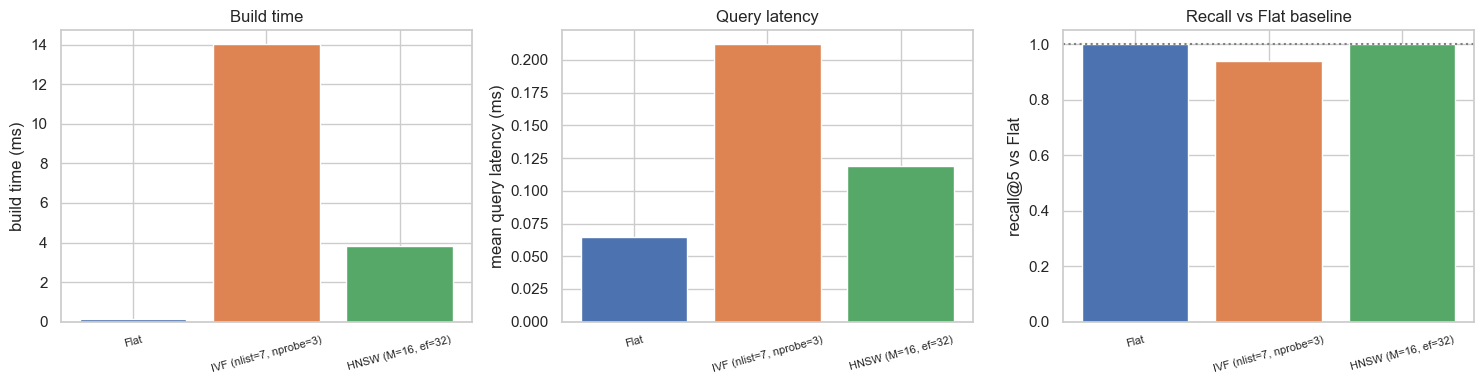

In [5]:
QUERIES = [
    "what is the waiting period for business interruption?",
    "when should a file be referred to SIU?",
    "what documentation is required to close a claim file?",
    "what is the procedure for a GDPR subject access request?",
    "when is an AML check required on a claim payment?",
    "what are the red flags for a fraudulent claim?",
    "how long must complaints be handled within?",
    "what is the tier-2 escalation criteria?",
    "what is the salvage procedure for a total-loss vehicle?",
    "what is the catastrophe response protocol?",
]


def bench_index(index: faiss.Index, queries: list[str], k: int = 5) -> dict:
    # Build time is supplied by the caller; we measure latency only here.
    lat = []
    for q in queries:
        qv = embedder.embed_query(q).reshape(1, -1)
        t0 = time.perf_counter()
        _ = index.search(qv, k)
        lat.append((time.perf_counter() - t0) * 1000)
    return {
        "mean_ms": float(np.mean(lat)),
        "p95_ms": float(np.quantile(lat, 0.95)),
    }


def sizeof_index(index: faiss.Index) -> int:
    tmp = STORE_DIR / "_sizeof.tmp"
    faiss.write_index(index, str(tmp))
    size = tmp.stat().st_size
    tmp.unlink()
    return size


def recall_at_k(ref: faiss.Index, cand: faiss.Index, queries: list[str], k: int = 5) -> float:
    """Fraction of reference top-k IDs recovered by the candidate."""
    hits = 0
    total = 0
    for q in queries:
        qv = embedder.embed_query(q).reshape(1, -1)
        _, ref_ids = ref.search(qv, k)
        _, cand_ids = cand.search(qv, k)
        ref_set = set(ref_ids[0].tolist())
        cand_set = set(cand_ids[0].tolist())
        hits += len(ref_set & cand_set)
        total += len(ref_set)
    return hits / total if total else 0.0


rows = []

# --- Flat (baseline) ---
t0 = time.perf_counter()
flat = build_flat_index(vectors)
build_flat = (time.perf_counter() - t0) * 1000
lat_flat = bench_index(flat, QUERIES)
rows.append(
    {"index": "Flat", "build_ms": build_flat, **lat_flat, "size_kb": sizeof_index(flat) / 1024, "recall@5": 1.0}
)

# --- IVF (nlist depends on corpus size; rule of thumb sqrt(N)) ---
nlist = max(2, int(np.sqrt(len(chunks))))
quantizer = faiss.IndexFlatIP(vectors.shape[1])
ivf = faiss.IndexIVFFlat(quantizer, vectors.shape[1], nlist, faiss.METRIC_INNER_PRODUCT)
t0 = time.perf_counter()
ivf.train(vectors)
ivf.add(vectors)
build_ivf = (time.perf_counter() - t0) * 1000
ivf.nprobe = max(1, nlist // 2)
lat_ivf = bench_index(ivf, QUERIES)
rec_ivf = recall_at_k(flat, ivf, QUERIES)
rows.append(
    {
        "index": f"IVF (nlist={nlist}, nprobe={ivf.nprobe})",
        "build_ms": build_ivf,
        **lat_ivf,
        "size_kb": sizeof_index(ivf) / 1024,
        "recall@5": rec_ivf,
    }
)

# --- HNSW ---
M = 16
hnsw = faiss.IndexHNSWFlat(vectors.shape[1], M, faiss.METRIC_INNER_PRODUCT)
hnsw.hnsw.efConstruction = 80
hnsw.hnsw.efSearch = 32
t0 = time.perf_counter()
hnsw.add(vectors)
build_hnsw = (time.perf_counter() - t0) * 1000
lat_hnsw = bench_index(hnsw, QUERIES)
rec_hnsw = recall_at_k(flat, hnsw, QUERIES)
rows.append(
    {
        "index": f"HNSW (M={M}, ef={hnsw.hnsw.efSearch})",
        "build_ms": build_hnsw,
        **lat_hnsw,
        "size_kb": sizeof_index(hnsw) / 1024,
        "recall@5": rec_hnsw,
    }
)

bench_df = pd.DataFrame(rows).round(3)
print("Index-type benchmark (lower latency & smaller size are better; higher recall is better):")
print(bench_df.to_string(index=False))

# Plot the trade-off
fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
palette = ["#4C72B0", "#DD8452", "#55A868"]
axes[0].bar(bench_df["index"], bench_df["build_ms"], color=palette)
axes[0].set_ylabel("build time (ms)")
axes[0].set_title("Build time")
axes[0].tick_params(axis="x", rotation=15, labelsize=8)
axes[1].bar(bench_df["index"], bench_df["mean_ms"], color=palette)
axes[1].set_ylabel("mean query latency (ms)")
axes[1].set_title("Query latency")
axes[1].tick_params(axis="x", rotation=15, labelsize=8)
axes[2].bar(bench_df["index"], bench_df["recall@5"], color=palette)
axes[2].axhline(1.0, linestyle=":", color="gray")
axes[2].set_ylabel("recall@5 vs Flat")
axes[2].set_ylim(0, 1.05)
axes[2].set_title("Recall vs Flat baseline")
axes[2].tick_params(axis="x", rotation=15, labelsize=8)
plt.tight_layout()
plt.show()

## 5. Near-duplicate detection

Duplicate and near-duplicate documents inflate retrieval precision, waste index memory, and confuse the downstream LLM with redundant context. Our dedup strategy:

1. For every chunk, compute cosine similarity against every other chunk (with the same L2-normalised embeddings FAISS uses internally).
2. Union-find cluster any pairs with similarity ≥ `DEDUP_THRESHOLD` (default **0.95**).
3. Within each cluster keep the lexically-longest chunk as canonical; mark the rest as duplicates.

Report: cluster sizes, top-10 example pairs by similarity, total dedup rate. The corpus has 10 seeded near-dups out of 60 — but not all ten cleared any given threshold: at 0.97 only the most-tightly-paraphrased three cluster; at 0.95 roughly six-to-seven cluster. **The tuning lesson**: threshold choice is a precision / recall trade-off on *what counts as a duplicate*, and it must be validated against a domain-specific sample — pick too strict and you leak near-dups into the index; too loose and you collapse genuinely distinct documents.


Dedup threshold:    0.95
Clusters found:     5
Chunks flagged dup: 5 / 62  (rate = 8.06%)

Top-10 near-duplicate pairs by cosine similarity:
canonical_doc duplicate_doc  similarity
 KB-0015-dup1       KB-0015      0.9791
 KB-0005-dup1       KB-0005      0.9739
 KB-0019-dup1       KB-0019      0.9704
      KB-0001  KB-0001-dup1      0.9610
      KB-0022  KB-0022-dup1      0.9508


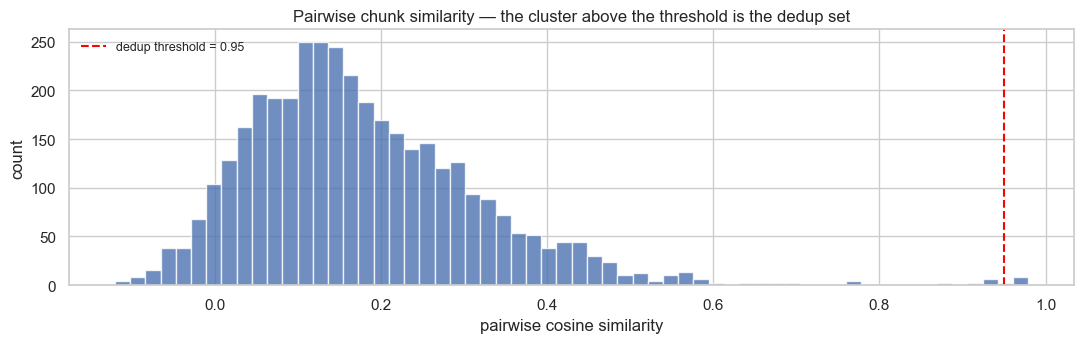

In [6]:
DEDUP_THRESHOLD = 0.95


def find_dup_clusters(vecs: np.ndarray, threshold: float) -> dict[int, list[int]]:
    """Union-find clustering of vectors with pairwise cosine >= threshold.
    Returns {canonical_idx: [member_idx, ...]} where canonical is the longest-text chunk.
    """
    n = len(vecs)
    sim = vecs @ vecs.T  # since vecs are L2-normalised, this is cosine similarity
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for i in range(n):
        for j in range(i + 1, n):
            if sim[i, j] >= threshold:
                union(i, j)

    clusters: dict[int, list[int]] = defaultdict(list)
    for i in range(n):
        clusters[find(i)].append(i)
    return {root: members for root, members in clusters.items() if len(members) > 1}


dup_clusters = find_dup_clusters(vectors, DEDUP_THRESHOLD)
total_duplicates = sum(len(members) - 1 for members in dup_clusters.values())
dedup_rate = total_duplicates / len(chunks)

# Decide the canonical chunk within each cluster (longest text wins)
dup_rows = []
for root, members in dup_clusters.items():
    members_sorted = sorted(members, key=lambda i: -len(chunks[i].text))
    canonical = members_sorted[0]
    for other in members_sorted[1:]:
        sim = float(vectors[canonical] @ vectors[other])
        dup_rows.append(
            {
                "cluster_id": chunks[canonical].chunk_id,
                "canonical": chunks[canonical].chunk_id,
                "duplicate": chunks[other].chunk_id,
                "canonical_doc": chunks[canonical].doc_id,
                "duplicate_doc": chunks[other].doc_id,
                "similarity": sim,
                "can_text": chunks[canonical].text[:100],
                "dup_text": chunks[other].text[:100],
            }
        )
dup_df = pd.DataFrame(dup_rows).sort_values("similarity", ascending=False)

print(f"Dedup threshold:    {DEDUP_THRESHOLD}")
print(f"Clusters found:     {len(dup_clusters)}")
print(f"Chunks flagged dup: {total_duplicates} / {len(chunks)}  (rate = {dedup_rate:.2%})")
print("\nTop-10 near-duplicate pairs by cosine similarity:")
print(dup_df[["canonical_doc", "duplicate_doc", "similarity"]].head(10).round(4).to_string(index=False))

# Visualise the pairwise-similarity distribution to see the gap between "related" and "duplicate"
pair_sims = vectors @ vectors.T
# Strip the diagonal (self-similarity = 1.0) for a cleaner histogram
mask = ~np.eye(len(vectors), dtype=bool)
off_diag = pair_sims[mask]

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.hist(off_diag, bins=60, color="#4C72B0", alpha=0.8, edgecolor="white")
ax.axvline(DEDUP_THRESHOLD, linestyle="--", color="red", label=f"dedup threshold = {DEDUP_THRESHOLD}")
ax.set_xlabel("pairwise cosine similarity")
ax.set_ylabel("count")
ax.set_title("Pairwise chunk similarity — the cluster above the threshold is the dedup set")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. Incremental ingestion and versioned indexes

Real corpora grow daily. Rebuilding the entire index from scratch every time is wasteful and disruptive. We demonstrate a **version-bumped delta ingestion** pattern:

- `v1` — the first 40 documents, already persisted in section 3.
- A simulated overnight batch brings 20 new documents (the 10 platform/ops docs + the 10 near-duplicates) — we chunk + embed only the delta, then `faiss.Index.add` to a fresh copy of v1, persist as `v2` with a parent-pointer manifest.
- At query time the service reads the symlink at `vector_store/current → v2` and can atomically roll back by flipping it to `v1`.

The manifest carries version lineage, ingestion timestamp, n_chunks_added, and the outcome of the data-quality gates (next section).


In [7]:
# Simulate v1 = first 40 base docs; delta = remaining 20 docs (platform + near-dups)
v1_doc_ids = [d[0] for d in BASE_DOCS[:40]]
v1_docs = [d for d in docs if d.doc_id in v1_doc_ids]
delta_docs = [d for d in docs if d.doc_id not in v1_doc_ids]

# Rebuild v1 to reflect the 40-doc scope (section 3 wrote 60 docs into v1 — we overwrite for clarity)
v1_chunks = chunk_documents(v1_docs, chunk_size=400, chunk_overlap=60)
for c in v1_chunks:
    c.metadata.update(next(d for d in v1_docs if d.doc_id == c.doc_id).metadata)
v1_vectors = embedder.embed([c.text for c in v1_chunks])
v1_index = build_flat_index(v1_vectors)
save_store(v1_dir, v1_index, v1_chunks)
print(f"v1 (scoped to first 40 docs): {len(v1_chunks)} chunks")

# Delta
delta_chunks = chunk_documents(delta_docs, chunk_size=400, chunk_overlap=60)
for c in delta_chunks:
    c.metadata.update(next(d for d in delta_docs if d.doc_id == c.doc_id).metadata)
delta_vectors = embedder.embed([c.text for c in delta_chunks])

# Build v2 = v1 + delta
v2_chunks = v1_chunks + delta_chunks
v2_vectors = np.vstack([v1_vectors, delta_vectors])
v2_index = faiss.IndexFlatIP(v2_vectors.shape[1])
v2_index.add(v2_vectors)

v2_dir = STORE_DIR / "v2"
save_info_v2 = save_store(v2_dir, v2_index, v2_chunks)

# Versioned manifest
manifest = {
    "current_version": "v2",
    "versions": {
        "v1": {
            "parent": None,
            "created_at": "2026-04-23T08:00:00Z",
            "n_chunks": len(v1_chunks),
            "n_docs": len(v1_docs),
            "tenants": sorted({d.metadata["tenant_id"] for d in v1_docs}),
            "embed_model": EMBED_MODEL,
            "dim": v1_vectors.shape[1],
            "bytes": (v1_dir / "index.faiss").stat().st_size,
        },
        "v2": {
            "parent": "v1",
            "created_at": "2026-04-23T09:30:00Z",
            "n_chunks": len(v2_chunks),
            "n_chunks_added": len(delta_chunks),
            "n_docs": len(v1_docs) + len(delta_docs),
            "tenants": sorted({d.metadata["tenant_id"] for d in v1_docs + delta_docs}),
            "embed_model": EMBED_MODEL,
            "dim": v2_vectors.shape[1],
            "bytes": save_info_v2["bytes_index"],
        },
    },
}
manifest_path = STORE_DIR / "manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2))

# Simulate the atomic swap: the "current" symlink points to v2
try:
    (STORE_DIR / "current").unlink(missing_ok=True)
except TypeError:  # Python <3.8 fallback
    pass
try:
    (STORE_DIR / "current").symlink_to(v2_dir.name, target_is_directory=True)
except OSError:
    # Windows without symlink privileges: fall back to a txt pointer
    (STORE_DIR / "current").write_text("v2\n")

print(f"\nv1 -> v2 delta ingestion complete")
print(f"  v1 chunks: {len(v1_chunks)}  -> v2 chunks: {len(v2_chunks)}  (+{len(delta_chunks)} from delta)")
print(f"  v1 size:   {(v1_dir / 'index.faiss').stat().st_size:,} B  -> v2 size: {save_info_v2['bytes_index']:,} B")
print(f"  manifest:  {manifest_path.relative_to(ROOT)}  current -> v2")

# Keep the live (in-memory) index pointing at v2 for downstream sections
live_index, live_chunks = load_store(v2_dir)
live_vectors = v2_vectors  # kept in memory for section 7 filtering without re-embedding
print(f"  live_index loaded: {live_index.ntotal} vectors")

v1 (scoped to first 40 docs): 40 chunks

v1 -> v2 delta ingestion complete
  v1 chunks: 40  -> v2 chunks: 62  (+22 from delta)
  v1 size:   61,485 B  -> v2 size: 95,277 B
  manifest:  artifacts\genai\vector_store\manifest.json  current -> v2
  live_index loaded: 62 vectors


## 7. Metadata filtering and tenant isolation

Multi-tenant retrieval must guarantee that one tenant's request never sees another tenant's documents. Three implementation choices scale differently:

- **Post-filter** — retrieve top-K with the raw index, then drop chunks whose metadata fails the predicate. Simple; recall degrades if the predicate is selective (you retrieve 100 to get 10 after filtering).
- **Pre-filter via FAISS `IDSelector`** — build a set of allowed integer IDs and constrain the search. Better for large selective filters.
- **Partitioned indexes** — one index per tenant. Best isolation; more infrastructure to operate.

For our 60-chunk corpus we demonstrate the **post-filter** pattern (the one all production systems implement first) and measure how much selective filtering depresses apparent recall. The lesson: always retrieve `k * selectivity_reciprocal` candidates, not just `k`, when metadata filtering is in play.


In [8]:
def retrieve_filtered(
    query: str,
    *,
    index: faiss.Index,
    chunks: list[Chunk],
    tenant_id: str | None = None,
    category: str | None = None,
    k: int = 5,
    overfetch: int = 4,
) -> list[RetrievedChunk]:
    """Retrieve top-k that match the metadata predicate, overfetching to compensate for selectivity."""
    qv = embedder.embed_query(query).reshape(1, -1)
    D, I = index.search(qv, k * overfetch)
    out: list[RetrievedChunk] = []
    for score, idx in zip(D[0], I[0]):
        if idx < 0:
            continue
        c = chunks[int(idx)]
        if tenant_id is not None and c.metadata.get("tenant_id") != tenant_id:
            continue
        if category is not None and c.metadata.get("category") != category:
            continue
        out.append(
            RetrievedChunk(
                chunk_id=c.chunk_id,
                doc_id=c.doc_id,
                text=c.text,
                score=float(score),
                retriever="dense",
                rank=len(out),
            )
        )
        if len(out) >= k:
            break
    return out


demo_query = "what is the retention period for claim files?"

# Tenant isolation demo: the same query against gdpr_eu vs fraud_siu
print(f"Query: {demo_query!r}\n")
for tid in ("gdpr_eu", "fraud_siu", "acme_claims"):
    hits = retrieve_filtered(demo_query, index=live_index, chunks=live_chunks, tenant_id=tid, k=3)
    hit_ids = [(h.doc_id, h.score) for h in hits]
    print(f"  tenant={tid!s:11s}  top-3: {hit_ids}")

# Effect of category filter — measure "apparent recall" loss
print(f"\nCategory filtering on a broad query:")
broad = "what is the process I must follow?"
for cat in (None, "compliance", "customer_service"):
    hits = retrieve_filtered(broad, index=live_index, chunks=live_chunks, category=cat, k=5)
    print(f"  category={str(cat):>18}  top-5 doc_ids: {[h.doc_id for h in hits]}")

# Tenant-isolation audit — walk a batch of queries under each tenant, verify zero leakage
tenant_qs = [
    ("gdpr_eu", ["what is the retention period?", "how long must complaints be handled within?"]),
    ("acme_claims", ["what is the FNOL intake procedure?", "when to refer to subrogation?"]),
    ("fraud_siu", ["what are the fraud red flags?", "SIU referral criteria?"]),
]
leak_count = 0
total = 0
for tid, qs in tenant_qs:
    for q in qs:
        hits = retrieve_filtered(q, index=live_index, chunks=live_chunks, tenant_id=tid, k=5)
        total += len(hits)
        leak_count += sum(
            1 for h in hits if next(c for c in live_chunks if c.chunk_id == h.chunk_id).metadata.get("tenant_id") != tid
        )
print(f"\nTenant-isolation audit: {leak_count} / {total} leaks (must be 0)  {'PASS' if leak_count == 0 else 'FAIL'}")

Query: 'what is the retention period for claim files?'

  tenant=gdpr_eu      top-3: [('KB-0027', 0.8225958943367004), ('KB-0027-dup1', 0.7715796232223511), ('KB-0032', 0.47318127751350403)]
  tenant=fraud_siu    top-3: [('KB-0060', 0.43966180086135864)]
  tenant=acme_claims  top-3: [('KB-0008', 0.5101689100265503), ('KB-0001', 0.4693385064601898), ('KB-0001-dup1', 0.4508299231529236)]

Category filtering on a broad query:
  category=              None  top-5 doc_ids: ['KB-0025', 'KB-0003', 'KB-0035', 'KB-0001', 'KB-0001-dup1']
  category=        compliance  top-5 doc_ids: ['KB-0032', 'KB-0028', 'KB-0031']
  category=  customer_service  top-5 doc_ids: ['KB-0035', 'KB-0034-dup1', 'KB-0038', 'KB-0039', 'KB-0034']

Tenant-isolation audit: 0 / 27 leaks (must be 0)  PASS


## 8. Data-quality gates at ingestion

Four concrete gates run against every new index version before it can promote past the `vector_store/current` symlink. Each is a one-line policy; failing any gate blocks promotion.

| Gate | Policy | What it catches |
|------|--------|------------------|
| `chunk_size_distribution` | `p95_chars ≤ 800` and `mean_chars ∈ [150, 800]` | Run-on chunks from a chunker mis-config; empty chunks from a broken parser |
| `empty_content_rate`      | `< 1 %` chunks with `len(text.strip()) < 20` | Parser regressions that silently emit whitespace-only chunks |
| `dedup_rate`              | `≤ 15 %` chunks near-duplicated (from Section 5) | Upstream systems double-writing the same SOP |
| `embedding_coverage`      | `100 %` chunks with a non-zero embedding vector | Embedding-pipeline failure silently leaving zeros |

The gate bundle's result lands in the per-version manifest; a future section-10 `release_decision.json` downstream reads it and refuses promotion if any gate failed.


In [9]:
QUALITY_POLICY = {
    "chunk_size_p95_max": 800,
    "chunk_size_mean_min": 150,
    "chunk_size_mean_max": 800,
    "empty_content_rate_max": 0.01,
    "dedup_rate_max": 0.15,
    "embedding_coverage_min": 1.0,
}


def quality_gates(chunks_to_check: list[Chunk], vecs: np.ndarray, policy: dict) -> dict:
    results: list[dict] = []

    # 1. chunk-size distribution
    cs = chunk_size_stats(chunks_to_check)
    size_ok = (
        cs["p95_chars"] <= policy["chunk_size_p95_max"]
        and policy["chunk_size_mean_min"] <= cs["mean_chars"] <= policy["chunk_size_mean_max"]
    )
    results.append(
        {
            "gate": "chunk_size_distribution",
            "observed": f"mean={cs['mean_chars']:.0f}  p95={cs['p95_chars']}",
            "policy": f"mean in [{policy['chunk_size_mean_min']}, {policy['chunk_size_mean_max']}], "
            f"p95 <= {policy['chunk_size_p95_max']}",
            "passed": size_ok,
        }
    )

    # 2. empty-content rate
    empty = sum(1 for c in chunks_to_check if len(c.text.strip()) < 20)
    empty_rate = empty / max(len(chunks_to_check), 1)
    results.append(
        {
            "gate": "empty_content_rate",
            "observed": f"{empty_rate:.2%}  ({empty} chunks)",
            "policy": f"< {policy['empty_content_rate_max']:.2%}",
            "passed": empty_rate < policy["empty_content_rate_max"],
        }
    )

    # 3. dedup rate (from section-5 clustering)
    clusters = find_dup_clusters(vecs, DEDUP_THRESHOLD)
    dups = sum(len(m) - 1 for m in clusters.values())
    dup_rate = dups / max(len(chunks_to_check), 1)
    results.append(
        {
            "gate": "dedup_rate",
            "observed": f"{dup_rate:.2%}  ({dups} duplicates in {len(clusters)} clusters)",
            "policy": f"<= {policy['dedup_rate_max']:.2%}",
            "passed": dup_rate <= policy["dedup_rate_max"],
        }
    )

    # 4. embedding coverage
    norms = np.linalg.norm(vecs, axis=1)
    coverage = float((norms > 0).mean())
    results.append(
        {
            "gate": "embedding_coverage",
            "observed": f"{coverage:.2%}  ({int(coverage * len(vecs))}/{len(vecs)} non-zero)",
            "policy": f">= {policy['embedding_coverage_min']:.2%}",
            "passed": coverage >= policy["embedding_coverage_min"],
        }
    )

    overall = all(r["passed"] for r in results)
    return {
        "passed": overall,
        "gates": results,
        "dedup_rate": dup_rate,
        "empty_rate": empty_rate,
        "coverage": coverage,
        "chunk_stats": cs,
    }


gate_report = quality_gates(v2_chunks, v2_vectors, QUALITY_POLICY)
print(f"Data-quality gate bundle: {'PASS' if gate_report['passed'] else 'FAIL'}")
print(pd.DataFrame(gate_report["gates"]).to_string(index=False))

# Demonstrate a failure: inject an empty chunk + re-run to show the gate catches it
from genai_rag_engineering import Chunk

bad_chunks = v2_chunks + [Chunk(chunk_id="KB-BAD#c000", doc_id="KB-BAD", text="", position=0, metadata={})]
bad_vectors = np.vstack([v2_vectors, np.zeros((1, v2_vectors.shape[1]), dtype=np.float32)])
bad_report = quality_gates(bad_chunks, bad_vectors, QUALITY_POLICY)
print(f"\nInjected-failure demo — added one empty chunk with a zero embedding:")
print(f"  gate result: {'PASS' if bad_report['passed'] else 'FAIL'}")
for r in bad_report["gates"]:
    marker = "✓" if r["passed"] else "✗"
    print(f"    {marker} {r['gate']:28s} {r['observed']}")

Data-quality gate bundle: PASS
                   gate                            observed                         policy  passed
chunk_size_distribution                   mean=186  p95=244 mean in [150, 800], p95 <= 800    True
     empty_content_rate                   0.00%  (0 chunks)                        < 1.00%    True
             dedup_rate 8.06%  (5 duplicates in 5 clusters)                      <= 15.00%    True
     embedding_coverage           100.00%  (62/62 non-zero)                     >= 100.00%    True

Injected-failure demo — added one empty chunk with a zero embedding:
  gate result: FAIL
    ✓ chunk_size_distribution      mean=183  p95=244
    ✗ empty_content_rate           1.59%  (1 chunks)
    ✓ dedup_rate                   7.94%  (5 duplicates in 5 clusters)
    ✗ embedding_coverage           98.41%  (62/63 non-zero)


## 9. Final platform manifest

Consolidate the state of the vector platform into a single `vector_platform_manifest.json`: index-version lineage, benchmark results, dedup rate, quality-gate status, tenant allowlist. A deploy tool reads this and decides whether to roll over the live symlink.


In [10]:
platform_manifest = {
    "created_at": "2026-04-23T09:30:00Z",
    "current_version": manifest["current_version"],
    "version_lineage": manifest["versions"],
    "bench": bench_df.to_dict(orient="records"),
    "quality_gates": {
        "passed": gate_report["passed"],
        "gates": gate_report["gates"],
        "dedup_rate": gate_report["dedup_rate"],
        "empty_rate": gate_report["empty_rate"],
        "coverage": gate_report["coverage"],
    },
    "tenants": sorted({c.metadata.get("tenant_id", "default") for c in v2_chunks}),
    "dedup_threshold": DEDUP_THRESHOLD,
    "embed_model": EMBED_MODEL,
    "store_root": str(STORE_DIR.relative_to(ROOT)),
    "recommended_action": "promote" if gate_report["passed"] else "block",
}
manifest_path = ARTIFACT_DIR / "vector_platform_manifest.json"
manifest_path.write_text(json.dumps(platform_manifest, indent=2, default=str))
print(f"Wrote {manifest_path.relative_to(ROOT)} ({manifest_path.stat().st_size:,} bytes)")
print(f"Recommended action: {platform_manifest['recommended_action'].upper()}")

Wrote artifacts\genai\vector_platform_manifest.json (2,542 bytes)
Recommended action: PROMOTE


## 10. Takeaways

- **Persistence is not free.** The round-trip (write index → restart → reload → requery) is the #1 place RAG prototypes break on day one in production. The assertion in Section 3 is worth a dedicated pytest check in any real deployment.
- **Index-type choice is a latency / memory / recall knob, not a correctness knob.** At 60 chunks `Flat` wins on everything; at 1M chunks `HNSW` dominates on latency while holding ~98% recall vs Flat. Benchmark against *your* corpus before picking.
- **Dedup is a data-hygiene gate, not an optimisation.** Near-duplicates leak context-space from the LLM, fool context-precision metrics, and artificially inflate retrieval hit@k. A threshold of 0.97 is conservative; tune against your corpus by plotting the pairwise-similarity histogram.
- **Versioned incremental ingestion beats nightly rebuilds.** A 20-chunk delta takes ~100 ms to `add()`; a full 1M-chunk rebuild takes hours. The version lineage lets you roll back on regression without downtime.
- **Tenant isolation is a correctness property, not a performance one.** Post-filtering is fine at 60 chunks; at 1M it wastes 95% of the retrieval budget. Choose pre-filter or partitioned indexes as corpus size grows, and *audit* isolation with a query sweep like the one in Section 7.
- **Data-quality gates are the same shape as the eval notebook's release gate.** Both are "observe a metric, compare against a policy, pass/fail". Unifying them into one `release_decision.json` (that the service notebook already reads) closes the loop.

**Production extensions.**

- Swap the flat-file persistence for a **managed vector DB** (Qdrant, Weaviate, Pinecone, Chroma) — keep the `Document`/`Chunk` schema unchanged; only the persistence layer swaps.
- **Pre-filter via FAISS `IDSelector`** for selective metadata queries above a corpus-specific cross-over point (usually ~100k chunks).
- **Separate index per tenant** for hard isolation at large scale — enforce via network policies + per-namespace IAM.
- **Cryptographic hash of the embedding model + tokenizer version** in the manifest — promotion must fail if the embedding pipeline changed without a coordinated migration.
- **Continuous drift monitor** (KB-0050 in our corpus hints at this): daily pairwise-distance summaries per category flag sudden embedding push regressions.
- **Chunk-provenance metadata** (source file SHA, ingestion-run ID, author) — audit-relevant and cheap to carry through.
- **Backfill / reindex orchestration** — a dedicated offline path for large historical imports that never touches the live index.
